# Kaggriculture
## 01 · Observation audit and feature hypotheses

The dataset is generated by agent interactions with the official farming simulator. We begin with the exact observations delivered to policy callbacks, preserving the boundary between visible game information and evaluator-only metadata.

In [1]:
import json
from pathlib import Path

import pandas as pd
import plotly.graph_objects as go
from IPython.display import display

from kaggriculture_research.artifacts import digest, file_digest
from kaggriculture_research.environment import engine_manifest, read_protocol
from kaggriculture_research.visuals import show_figure

ROOT = Path.cwd() if (Path.cwd() / "configs").exists() else Path.cwd().parent
summary = json.loads((ROOT / "reports/foundation.json").read_text())
assert summary["engine"] == engine_manifest(), "Stale engine lineage"
assert summary["feature_lineage"]["feature_code"] == file_digest(
    ROOT / "src/kaggriculture_research/features.py"
), "Stale features"
assert summary["feature_lineage"]["audit_code"] == file_digest(
    ROOT / "src/kaggriculture_research/audit.py"
), "Stale audit"
assert summary["feature_lineage"]["protocol_sha256"] == digest(read_protocol(ROOT)), (
    "Stale protocol"
)
assert not summary["holdout_used"]

In [2]:
registry = pd.read_csv(ROOT / "reports/feature_registry.csv")
trajectories = pd.read_csv(ROOT / "reports/trajectories.csv")
display(
    pd.Series(
        {
            "Agent observations": summary["callback_observations"],
            "Candidate descriptors": summary["candidate_features"],
            "Feature families": len(summary["family_counts"]),
            "Missing/non-finite values": summary["missing_values"],
            "Constant in this narrow reference": len(summary["constant_in_reference_rollouts"]),
            "Screened for model selection": summary["screened_for_selection"],
            "Retained / rejected for a model": "0 / 0",
        },
        name="Observation audit",
    ).to_frame()
)

,Observation audit
Agent observations,11504
Candidate descriptors,244
Feature families,8
Missing/non-finite values,0
Constant in this narrow reference,146
Screened for model selection,0
Retained / rejected for a model,0 / 0


### Information available at a decision

Both farms, their public crops/animals, worker positions, cash, market inventory/prices, and currently unlocked shops are visible. Only our own shed, carried inventory, and seeds are visible. The extractor excludes the episode seed, future shops, terminal reward, opponent private inventory, and future replay observations.

Temporal features in the next phase will use only earlier observations within the same episode. Target-derived encodings require episode-grouped out-of-fold fitting; a random split of turns would contaminate validation.

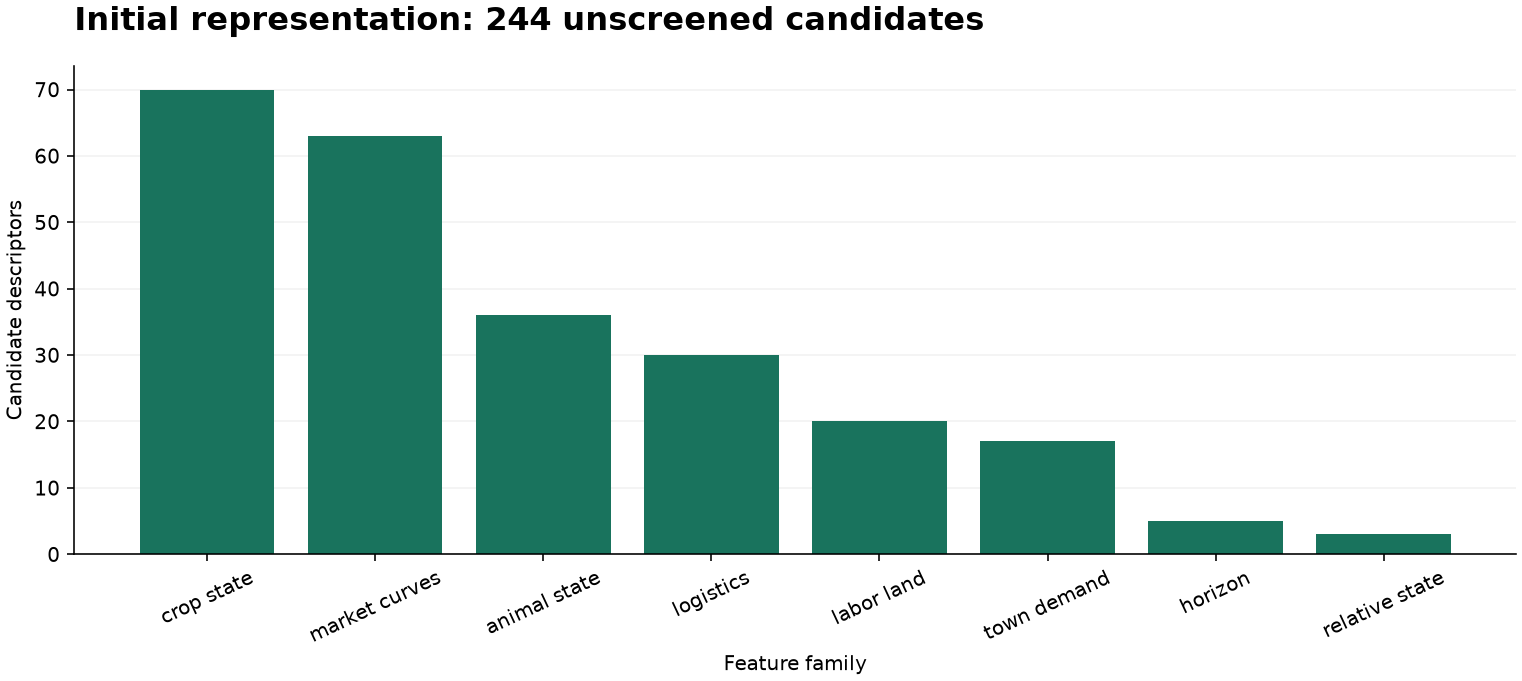

In [3]:
counts = registry.groupby("family").size().sort_values(ascending=False)
fig = go.Figure(
    go.Bar(
        x=[s.replace("_", " ") for s in counts.index],
        y=counts.tolist(),
        name="Unscreened candidates",
    )
)
fig.update_layout(
    title="Initial representation: 244 unscreened candidates",
    xaxis_title="Feature family",
    yaxis_title="Candidate descriptors",
)
show_figure(fig)

### Market behavior motivates decision features

Town shops consume goods independently, including duplicate shops. The resulting market inventory affects nonlinear sale prices. Current demand is observable, but the identity of a future shop is not. The curves below come from actual completed development episodes.

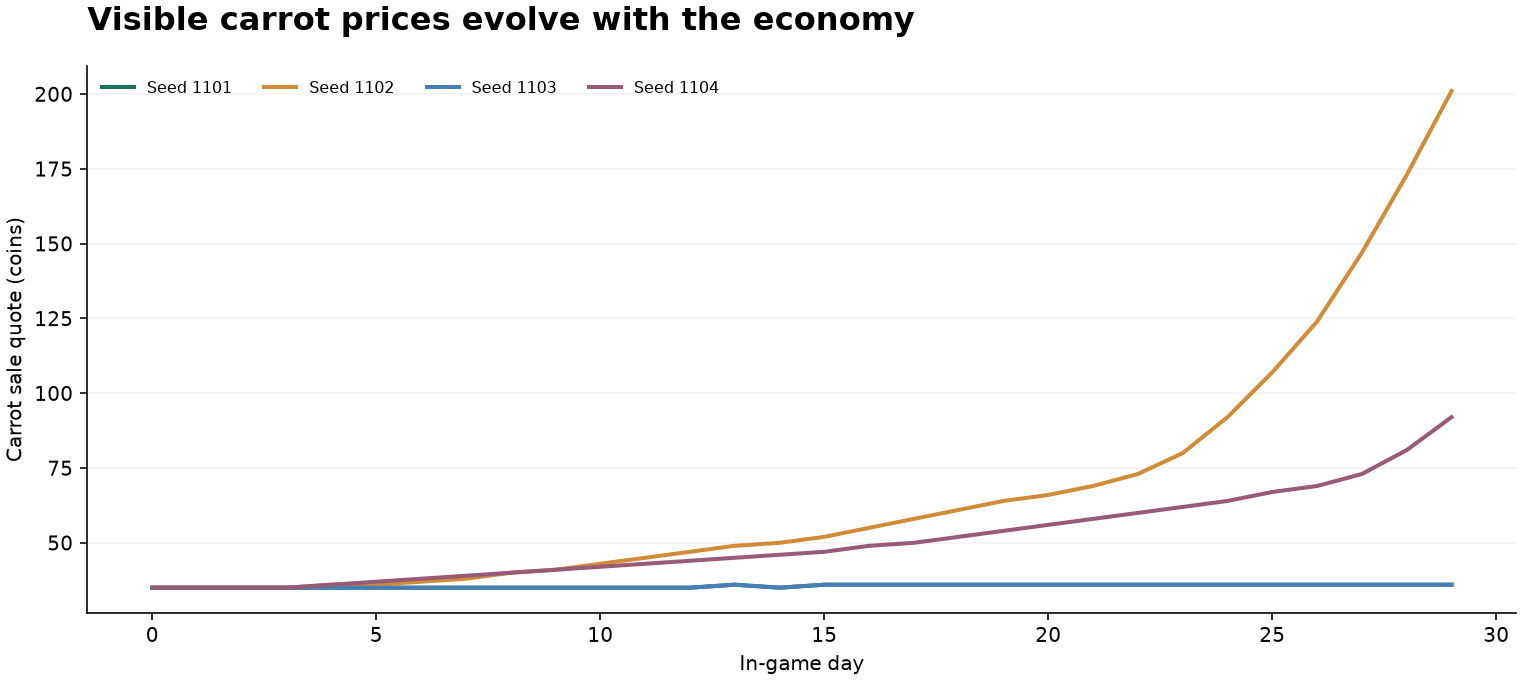

In [4]:
fig = go.Figure()
for seed, group in trajectories.groupby("seed"):
    means = group.groupby("day")["carrot_price"].mean()
    fig.add_scatter(x=means.index.tolist(), y=means.tolist(), mode="lines", name=f"Seed {seed}")
fig.update_layout(
    title="Visible carrot prices evolve with the economy",
    xaxis_title="In-game day",
    yaxis_title="Carrot sale quote (coins)",
)
show_figure(fig)

### A sale quote is not batch value

Selling changes the price received on later units. The initial candidates include exact immediate-sale scenarios for 5 and 20 units, assuming the opponent submits no simultaneous order. The transaction calculation is checked against the official interpreter. It is a conditional scenario, not a forecast of future demand or the opponent.

In [5]:
from kaggriculture_research.environment import game
from kaggriculture_research.features import sale_revenue

rows = []
for item in game.PRODUCTS:
    inv = game.MARKET_PARAMS[item]["I0"]
    quote = game.market_price(item, inv)
    rows.append(
        {
            "Product": item.title(),
            "Spot quote × 20": quote * 20,
            "Exact 20-unit immediate sale": sale_revenue(item, inv, 20),
        }
    )
display(pd.DataFrame(rows).set_index("Product"))

,Spot quote × 20,Exact 20-unit immediate sale
Product,,
Wheat,500,467.0
Carrot,700,634.0
Tomato,1200,1054.0
Strawberry,2400,2034.0
Melon,5000,4976.0
Egg,1000,927.0
Milk,3200,2802.0
Wool,4000,3856.0
Fertilizer,2000,1962.0


### Coverage flags are not rejection decisions

The starter/pass pair does not exercise livestock, land expansion, or coordinated labor. Many candidates therefore stay constant or coincide in this dataset. Removing them now would confuse a weak exploration policy with evidence that a feature has no value.

The next experiment needs richer farming strategies before training-only redundancy screening or feature-group ablation is meaningful.

In [6]:
coverage = (
    registry.assign(variable=registry["distinct_values_in_reference"] > 1)
    .groupby("family")
    .agg(candidates=("feature", "size"), varying_in_reference=("variable", "sum"))
)
coverage["constant_in_reference"] = coverage["candidates"] - coverage["varying_in_reference"]
display(coverage)
print("Model-selection screening, retention, and rejection remain at zero.")

,candidates,varying_in_reference,constant_in_reference
family,,,
animal_state,36,0,36
crop_state,70,12,58
horizon,5,5,0
labor_land,20,10,10
logistics,30,6,24
market_curves,63,49,14
relative_state,3,1,2
town_demand,17,15,2


Model-selection screening, retention, and rejection remain at zero.


### Next bounded experiment

1. Build a deterministic, legal crop-and-labor policy that generates broader state coverage.
2. Add crop lifecycle value, watering deadlines, hire value, and terminal liquidation features.
3. Compare controlled feature additions/removals on the same development seeds and opponents.

Keep feature research open until major plausible families have measured outcomes. See the [research protocol](../docs/research_protocol.md) for animal, market, logistics, opponent, and history families.

In [7]:
assert summary["gate"]["feature_research_complete"] is False
assert summary["gate"]["final_training_allowed"] is False
display(pd.Series(summary["gate"], name="Research gate").to_frame())

,Research gate
feature_research_complete,False
final_training_allowed,False
reason,No policy-driven feature screening or family a...
